# Create vector store for our system

In [1]:
# Load dataset 
from datasets import load_from_disk

ds_path = "../hf-dataset/panasonic-only-md-no-img-v0.1"
ds = load_from_disk(ds_path)
ds

/home/parsa/.conda/envs/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset({
    features: ['md_content', 'md_content_no_img_tbl'],
    num_rows: 7525
})

In [2]:
# 1. Remove empty
ds = ds.filter(lambda s: s["md_content_no_img_tbl"].strip() != "")

# 2. Remove low content
ds = ds.filter(lambda s: len(s["md_content_no_img_tbl"].split()) > 15)

# 3. Remove duplicates
seen = set()
def is_unique(sample):
    text = sample["md_content_no_img_tbl"].strip()
    if text in seen:
        return False
    seen.add(text)
    return True

ds = ds.filter(is_unique)

Filter: 100%|██████████| 7325/7325 [00:00<00:00, 32922.29 examples/s]


In [3]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("../models/embeddinggemma-300m", device='cuda')
tokenizer = model.tokenizer

In [4]:
from tqdm import tqdm
len_inputs = [len(tokenizer.encode(sample)) for sample in tqdm(ds['md_content_no_img_tbl'])]
len_inputs.sort()

100%|██████████| 7155/7155 [00:02<00:00, 2688.51it/s]


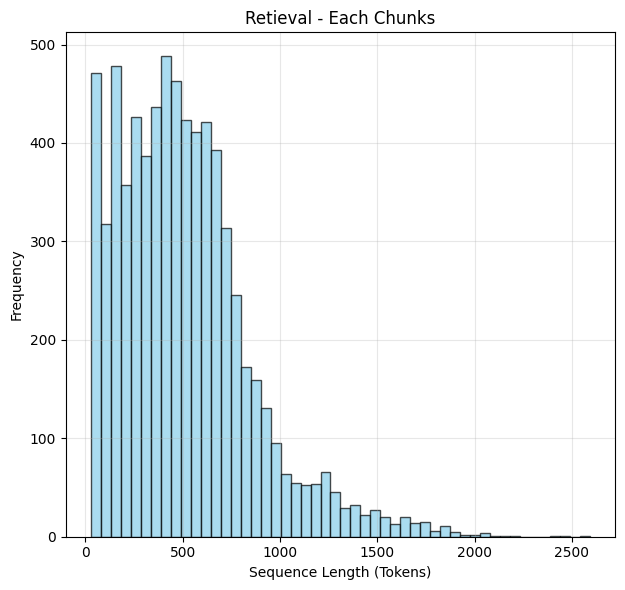

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(len_inputs, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Sequence Length (Tokens)')
plt.ylabel('Frequency')
plt.title('Retieval - Each Chunks')
plt.grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [6]:
from vector_store_module import Retriever

retriever = Retriever(index_path="./faiss_panasonic-only-md-no-img-v0.1/index", mapping_path="./faiss_panasonic-only-md-no-img-v0.1/id_map.json")


In [10]:
ds["md_content_no_img_tbl"][5]

'Panasonic\n\nProduct Change Notice\n\n# Product Change Notice - EVQ-P7, EVQ-PU and EVP-AF Series Light Touch Switches\n\nPCN.PG26.06.25.2013\n\n06.25.2013\n\n<table><tr><td>About this Notice:</td><td>In an effort to improve quality, Panasonic has decided to improve the packaging on these Light Touch Switch Series parts.</td></tr><tr><td>Effective Date:</td><td>June 7, 2013 or August 7, 2013 – See attached part number list for specific change dates.</td></tr><tr><td>Change Details:</td><td>To reduce the influence of electrostatic effects and improve packaging quality, Panasonic has changed the packaging cover film material. New package is slightly bluer in color. See below details.</td></tr><tr><td>Affected Parts:</td><td>See attached list.</td></tr><tr><td>Datasheet(s):</td><td>EVQ-P7/EVQ-P3/EVQ-9P7 Series Datasheet – see attachment.<br/>EVQ-PU Series Datasheet – see attachment<br/>EVP-AF Series Datasheet – see attachment</td></tr><tr><td>Notes:</td><td>See page 2 of this announcement

In [11]:
from tqdm import tqdm
for sample in tqdm(ds['md_content_no_img_tbl']):
    retriever.add_document(sample)

100%|██████████| 7155/7155 [04:17<00:00, 27.77it/s]


In [12]:
retriever.save()

In [1]:
res = retriever.search("motor sensor",3)

NameError: name 'retriever' is not defined

In [14]:
res

['Specifications\n\nVer.1.1\n\nProduct Name\n\nPIR MOTION SENSOR “PaPIRs”\n\nModel No.\n\nEKMC160511\n\nPage: 5\n\n## 5. Safety Precautions\n\nHead the following precautions to prevent injury or accidents.\n\n1. Do not use these sensors under any circumstance in which the range of their ratings, environment conditions or other specifications are exceeded.\nUsing the sensors in any way which causes their specifications to be exceeded may generate abnormally high levels of heat, emit smoke, etc., resulting in damage to the circuitry and possibly causing an accident.\n\n2. Our company is committed to making products of the highest quality and reliability.\nNevertheless, all electrical components are subject to natural deterioration, and durability of a product will depend on the operating environment and conditions of use. Continued use after such deterioration could lead to overheating, smoke or fire. Always use the product in conjunction with proper fire-prevention, safety and maintenan